<a href="https://colab.research.google.com/github/Kamal-0713/Handwritten_digits/blob/main/weather_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

In [ ]:
import pandas as pd

try:
    df = pd.read_csv('/content/seattle-weather.csv')
    print("seattle-weather.csv loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

except FileNotFoundError:
    print("Error: seattle-weather.csv not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")

seattle-weather.csv loaded successfully!
Dataset shape: (1461, 6)

First 5 rows of the dataset:
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [ ]:


    print("\n--- Initial Data Info ---")
    df.info()

    print("\n--- Missing Values ---")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
    if missing_values.empty:
        print("No missing values found in the dataset.")
    else:
        print(missing_values)




--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB

--- Missing Values ---
No missing values found in the dataset.



--- Target Variable Distribution (weather) ---


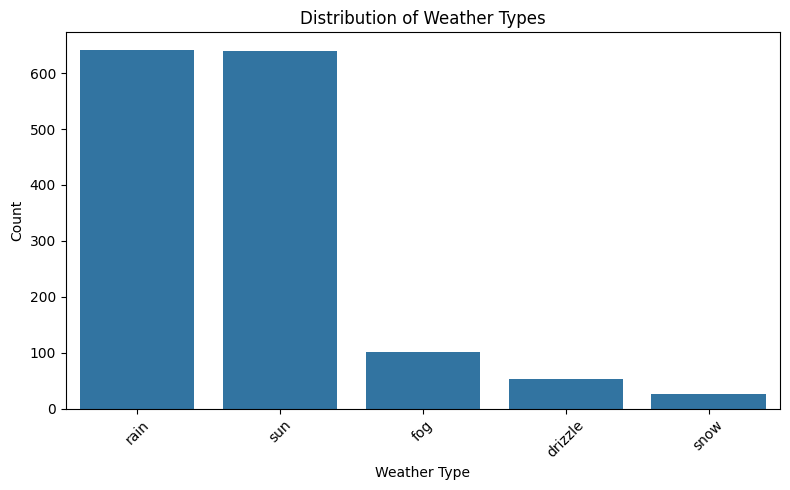

In [ ]:
print("\n--- Target Variable Distribution (weather) ---")
plt.figure(figsize=(8, 5))
sns.countplot(x='weather', data=df, order=df['weather'].value_counts().index)
plt.title('Distribution of Weather Types')
plt.xlabel('Weather Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
label_encoder = LabelEncoder()
df['weather_encoded'] = label_encoder.fit_transform(df['weather'])

# --- Separate Features and Target ---
X = df.drop(['weather', 'weather_encoded', 'date'], axis=1, errors='ignore')  # Drop non-numeric/date columns
y = df['weather_encoded']

# --- Separate Numerical and Categorical Columns ---
numeric_cols_dynamic = X.select_dtypes(include=np.number).columns.tolist()
object_cols_dynamic = X.select_dtypes(include='object').columns.tolist()

low_cardinality_cols = [col for col in numeric_cols_dynamic if X[col].nunique() < 20 and X[col].dtype in ['int64', 'float64']]
categorical_cols = list(set(object_cols_dynamic + low_cardinality_cols))
numerical_cols = [col for col in numeric_cols_dynamic if col not in categorical_cols]

print(f"\nNumber of numerical features identified: {len(numerical_cols)}")
print(f"Numerical features: {numerical_cols}")
print(f"Number of categorical features identified: {len(categorical_cols)}")
print(f"Categorical features: {categorical_cols}")

# --- Preprocessing Pipelines ---
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

# --- Evaluation Function (for Multiclass) ---
def evaluate_classifier(model_name, y_true, y_pred):
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# --- Model 1: Logistic Regression ---
print("\n--- Training Logistic Regression Model ---")
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42, max_iter=1000))])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
evaluate_classifier("Logistic Regression", y_test, y_pred_lr)

# --- Model 2: Random Forest ---
print("\n--- Training Random Forest Classifier Model ---")
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
evaluate_classifier("Random Forest Classifier", y_test, y_pred_rf)

# --- Model 3: K-Nearest Neighbors ---
print("\n--- Training K-Nearest Neighbors Classifier Model ---")
pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier(n_neighbors=5))])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
evaluate_classifier("K-Nearest Neighbors", y_test, y_pred_knn)

# --- Hyperparameter Tuning (Random Forest) ---
print("\n--- Hyperparameter Tuning for Random Forest ---")
param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10, None]
}
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_rf.best_params_}")
print(f"Best CV Accuracy: {grid_search_rf.best_score_:.4f}")
y_pred_best_rf = grid_search_rf.predict(X_test)
evaluate_classifier("Tuned Random Forest", y_test, y_pred_best_rf)


Number of numerical features identified: 4
Numerical features: ['precipitation', 'temp_max', 'temp_min', 'wind']
Number of categorical features identified: 0
Categorical features: []

Training set shape: (1168, 4), (1168,)
Testing set shape: (293, 4), (293,)

--- Training Logistic Regression Model ---

--- Logistic Regression Evaluation ---
Accuracy: 0.7816

Confusion Matrix:
[[  0   0   0   0  11]
 [  0   0   1   0  19]
 [  0   0 107   0  22]
 [  0   0   3   1   1]
 [  0   0   6   1 121]]

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        11
         fog       0.00      0.00      0.00        20
        rain       0.91      0.83      0.87       129
        snow       0.50      0.20      0.29         5
         sun       0.70      0.95      0.80       128

    accuracy                           0.78       293
   macro avg       0.42      0.39      0.39       293
weighted avg       0.71      0.78      0.74   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Random Forest Classifier Evaluation ---
Accuracy: 0.8123

Confusion Matrix:
[[  1   0   1   0   9]
 [  1   3   0   0  16]
 [  1   1 118   0   9]
 [  0   0   2   3   0]
 [  3  11   1   0 113]]

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.17      0.09      0.12        11
         fog       0.20      0.15      0.17        20
        rain       0.97      0.91      0.94       129
        snow       1.00      0.60      0.75         5
         sun       0.77      0.88      0.82       128

    accuracy                           0.81       293
   macro avg       0.62      0.53      0.56       293
weighted avg       0.80      0.81      0.80       293


--- Training K-Nearest Neighbors Classifier Model ---

--- K-Nearest Neighbors Evaluation ---
Accuracy: 0.6997

Confusion Matrix:
[[  1   1   0   0   9]
 [  3   3   2   0  12]
 [  0   3 107   0  19]
 [  0   1   2   1   1]
 [  3  15  17   0  93]]

Classification Report:
              preci

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
